In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from helpers.select_scenario import select_scenario
from helpers.load import *

In [2]:
scenario_folder = select_scenario()

Select a scenario:
[0]: lake
[1]: soil
Selected scenario: soil

Select a test run:
[0]: 2025-03-04_20:43  (areaSize .05 depth .05 sensors 20)
[1]: 2025-03-04_20:44 (areaSize .03 depth .03 sensors 40)
Selected run: 2025-03-04_20:44 (areaSize .03 depth .03 sensors 40)


In [3]:
node_pos_df = load_node_pos_df(scenario_folder)
tx_begin_df = load_phy_tx_begin(scenario_folder)
tx_end_df = load_phy_tx_end(scenario_folder)
tx_drop_df = load_phy_tx_drop(scenario_folder)
rx_begin_df = load_phy_rx_begin(scenario_folder)
rx_end_df = load_phy_rx_end(scenario_folder)
rx_drop_df = load_phy_rx_drop(scenario_folder)

In [4]:
def calculate_distances(node_pos_df, packet_df, src_col='SourceNodeId', dst_col='DestinationNodeId'):
   """Calculate distances between source and destination nodes for each packet.
   Store the distance in a new column in packet_df. Do all the math in pandas"""
   
   # Return empty series if packet_df is empty
   if len(packet_df) == 0:
      return pd.Series(dtype=float)
   
   # Merge node positions into packet_df
   df = packet_df.copy()
   df = df.merge(node_pos_df, left_on=src_col, right_on='NodeId')
   df = df.merge(node_pos_df, left_on=dst_col, right_on='NodeId', suffixes=('_src', '_dst'))
   
   # Calculate distance
   df['Distance'] = np.sqrt((df['X_src'] - df['X_dst'])**2 + (df['Y_src'] - df['Y_dst'])**2)
   
   return df['Distance']

In [5]:
# Calculate distances for all events
tx_begin_distances = calculate_distances(node_pos_df, tx_begin_df)
tx_end_distances = calculate_distances(node_pos_df, tx_end_df)
tx_drop_distances = calculate_distances(node_pos_df, tx_drop_df)
rx_begin_distances = calculate_distances(node_pos_df, rx_begin_df)
rx_end_distances = calculate_distances(node_pos_df, rx_end_df)
rx_drop_distances = calculate_distances(node_pos_df, rx_drop_df)

min_distance = float('inf')
max_distance = 0
for distances in [tx_begin_distances, tx_end_distances, tx_drop_distances, 
                  rx_begin_distances, rx_end_distances, rx_drop_distances]:
    if distances.empty:
        continue
    min_distance = min(min_distance, min(distances))
    max_distance = max(max_distance, max(distances))

# Create bins for histogram
bins = 10
bin_range = (min_distance, max_distance)

# Plot TX events
tx_hist_begin, _ = np.histogram(tx_begin_distances, bins=bins, range=bin_range)
tx_hist_end, _ = np.histogram(tx_end_distances, bins=bins, range=bin_range)
tx_hist_drop, _ = np.histogram(tx_drop_distances, bins=bins, range=bin_range)

# Plot RX events
rx_hist_begin, edges = np.histogram(rx_begin_distances, bins=bins, range=bin_range)
rx_hist_end, _ = np.histogram(rx_end_distances, bins=bins, range=bin_range)
rx_hist_drop, _ = np.histogram(rx_drop_distances, bins=bins, range=bin_range)

# Calculate bar positions
bar_width = 0.35
x = np.arange(len(edges)-1)

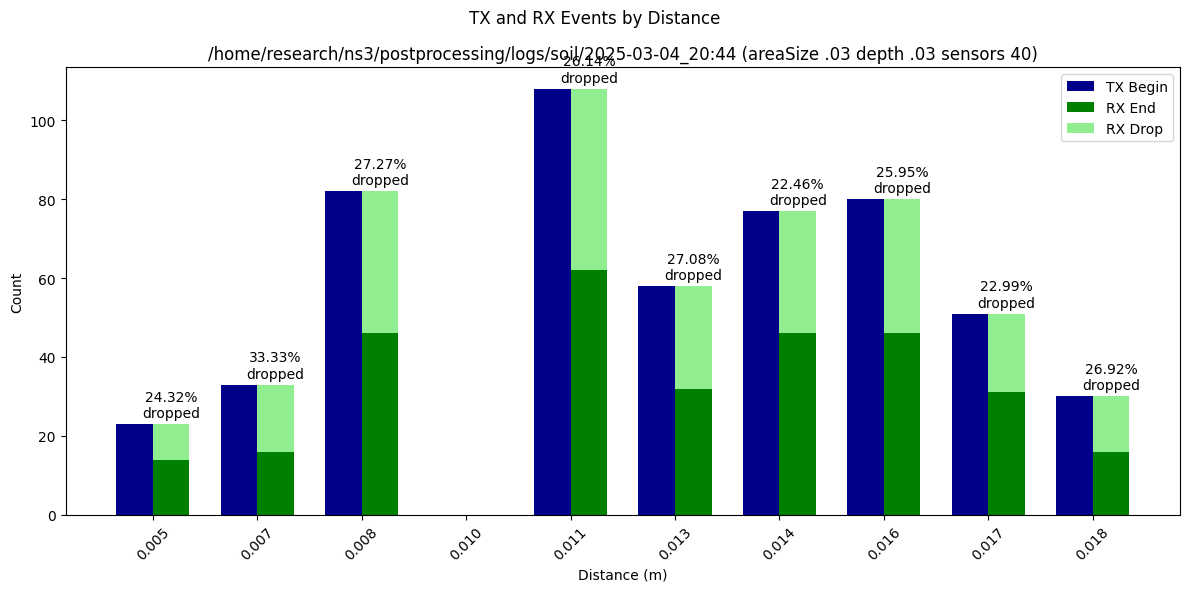

In [6]:
plt.figure(figsize=(12, 6))

plt.bar(x - bar_width/2, tx_hist_begin, bar_width, label='TX Begin', color='darkblue')
#plt.bar(x - bar_width/2, tx_hist_end, bar_width, bottom=tx_hist_begin, label='TX End', color='blue')
#plt.bar(x - bar_width/2, tx_hist_drop, bar_width, bottom=tx_hist_begin+tx_hist_end, label='TX Drop', color='lightblue')

#plt.bar(x + bar_width/2, rx_hist_begin, bar_width, label='RX Begin', color='darkgreen')
#plt.bar(x + bar_width/2, rx_hist_end, bar_width, bottom=rx_hist_begin, label='RX End', color='green')
#plt.bar(x + bar_width/2, rx_hist_drop, bar_width, bottom=rx_hist_begin+rx_hist_end, label='RX Drop', color='lightgreen')
plt.bar(x + bar_width/2, rx_hist_end, bar_width, label='RX End', color='green')
plt.bar(x + bar_width/2, rx_hist_drop, bar_width, bottom=rx_hist_end, label='RX Drop', color='lightgreen')

# Add label with % packets dropped/end for each bar
for i in range(len(edges)-1):
    total_rx = rx_hist_begin[i] + rx_hist_end[i] + rx_hist_drop[i]
    if total_rx > 0:
        height = rx_hist_end[i] + rx_hist_drop[i]
        plt.text(i + bar_width/2, height + 1, f'{rx_hist_drop[i]/total_rx:.2%}\ndropped', ha='center', va='bottom', color='black')


plt.xticks(x, [f'{(edges[i] + edges[i+1])/2:.3f}' for i in range(len(edges)-1)], rotation=45)
plt.xlabel('Distance (m)')
plt.ylabel('Count')
plt.suptitle('TX and RX Events by Distance')
plt.title(scenario_folder)
plt.legend()
plt.tight_layout()
plt.show()